In [30]:
import pandas as pd
import numpy as np

## Dataset

In [31]:
df = pd.read_csv("datasets/walmart/Walmart.csv")# https://www.kaggle.com/datasets/yasserh/walmart-dataset/data
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## Exploratory Data Analysis (EDA) (Brief)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [33]:
df["Date"].value_counts()

Date
05-02-2010    45
12-02-2010    45
19-02-2010    45
26-02-2010    45
05-03-2010    45
              ..
28-09-2012    45
05-10-2012    45
12-10-2012    45
19-10-2012    45
26-10-2012    45
Name: count, Length: 143, dtype: int64

array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'Weekly_Sales'}>,
        <Axes: title={'center': 'Holiday_Flag'}>],
       [<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Fuel_Price'}>,
        <Axes: title={'center': 'CPI'}>],
       [<Axes: title={'center': 'Unemployment'}>, <Axes: >, <Axes: >]],
      dtype=object)

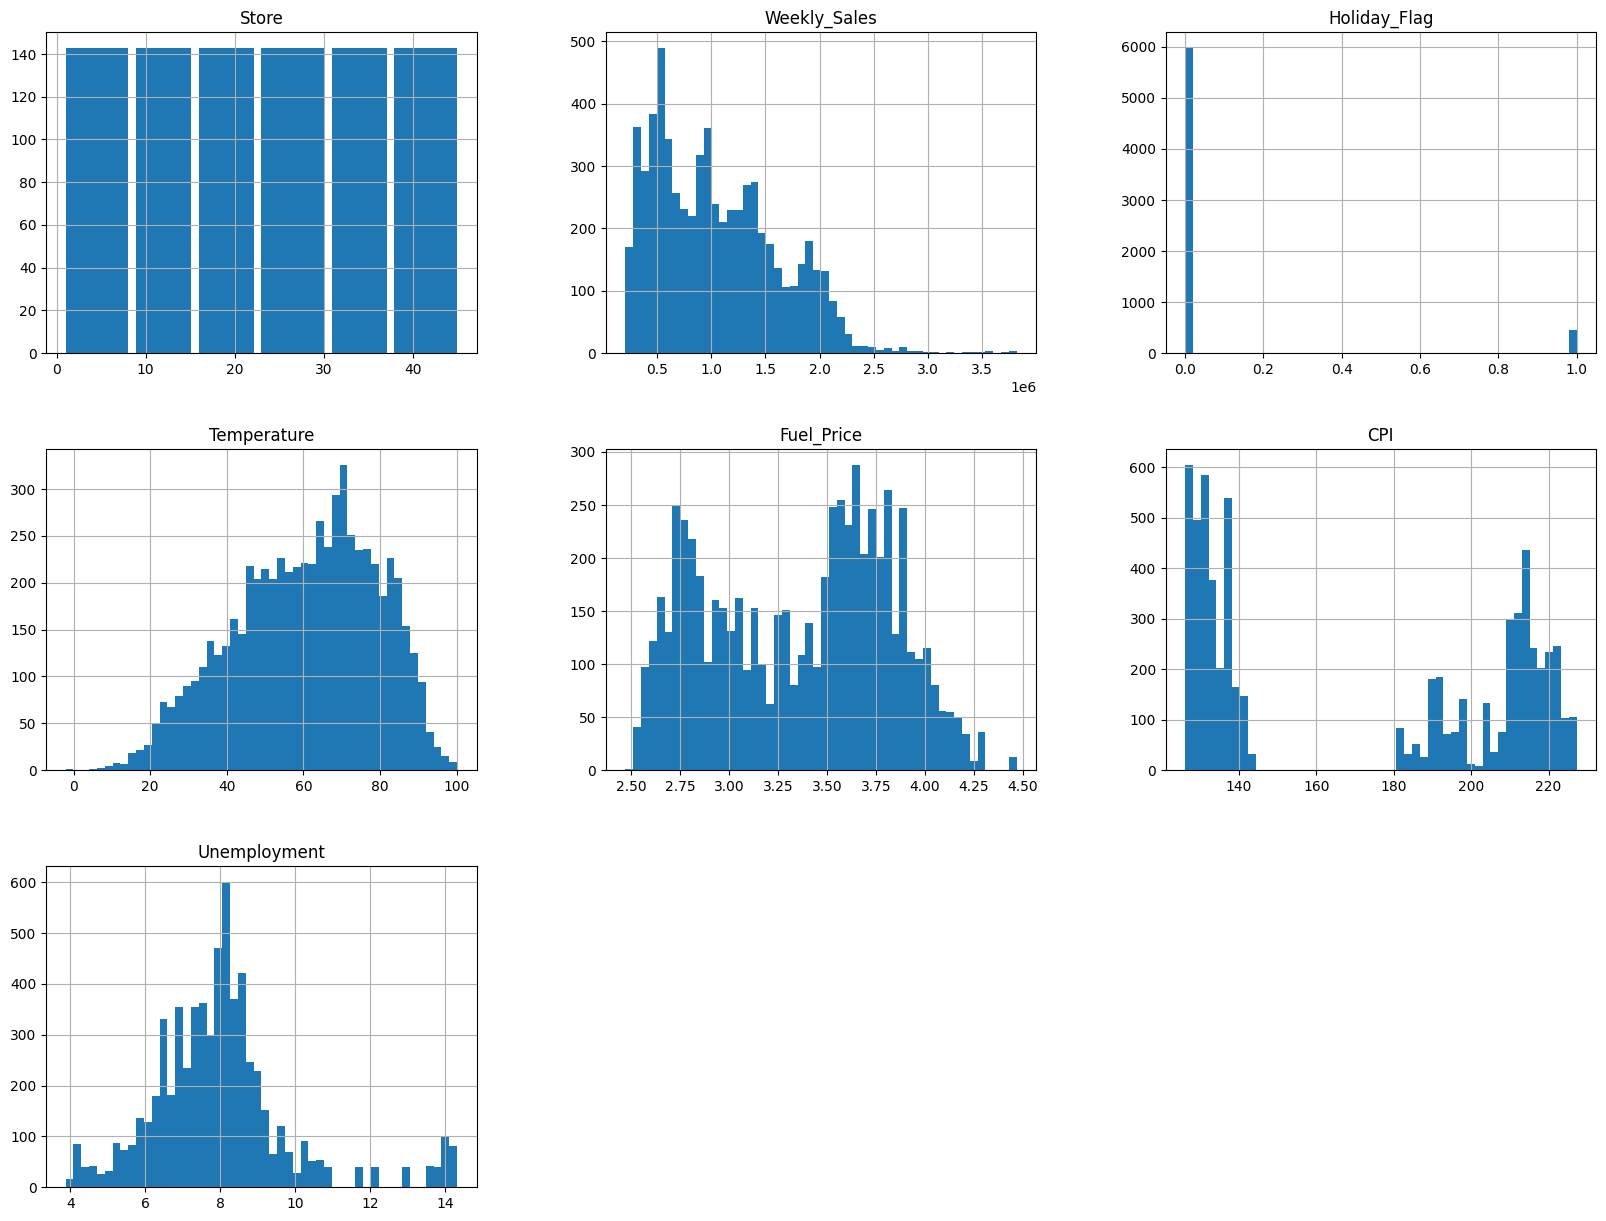

In [34]:
import matplotlib.pyplot as plt
%matplotlib inline
df.hist(bins=50, figsize=(20,15))

## Data Preprocessing

In [35]:
# df["Date"] = pd.to_datetime(df["Date"], format="mixed")# Google AI overview
# df["Date"] = (df['Date'] - pd.Timestamp("1970-01-01")).dt.total_seconds()# Google AI overview
# =====
# 3. Data Preprocessing from https://www.kaggle.com/code/yasserh/walmart-sales-prediction-best-ml-algorithms
df.Date = pd.to_datetime(df.Date, format='mixed')
df["Weekday"] = df.Date.dt.weekday
df["Month"] = df.Date.dt.month
#df["Year"] = df.Date.dt.year # Removing year because there may not be a useful pattern here
df = df.drop(["Date"], axis=1)

features = ["Month", "Weekday", "Store"]
for feature in features:
    one_hot = pd.get_dummies(df[feature], drop_first=True, prefix=feature)
    df = pd.concat([df, one_hot], axis=1)
    df = df.drop(feature, axis=1)
# =====

#df["Store"] = df["Store"].astype('category')
corr_matrix = df.corr()
corr_matrix["Weekly_Sales"].sort_values(ascending=False)

Weekly_Sales    1.000000
Store_20        0.283363
Store_4         0.279900
Store_14        0.260202
Store_13        0.255565
                  ...   
Store_38       -0.176645
Store_36       -0.179909
Store_5        -0.194736
Store_44       -0.198813
Store_33       -0.210270
Name: Weekly_Sales, Length: 67, dtype: float64

## Modelling

In [36]:
corr_matrix = df.corr()
corr_matrix["Weekly_Sales"].sort_values(ascending=False)

Weekly_Sales    1.000000
Store_20        0.283363
Store_4         0.279900
Store_14        0.260202
Store_13        0.255565
                  ...   
Store_38       -0.176645
Store_36       -0.179909
Store_5        -0.194736
Store_44       -0.198813
Store_33       -0.210270
Name: Weekly_Sales, Length: 67, dtype: float64

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
y = df["Weekly_Sales"]
X = df.drop(["Weekly_Sales"], axis=1)

In [39]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.1, random_state=42)

### Feature Scaling

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_X = scaler.fit_transform(train_X)
test_X  = scaler.transform(test_X)

### Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [42]:
reg.fit(train_X, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](66,)","[ 9044.82, -23712.63, -48432.54,..., -846620.04,-1109458.16, -685257.15]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.433e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,66
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,66
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](66,)","[38.46,32.21,25.37,..., 2.48, 2.36, 0.34]"


#### Linear Regression Score

In [14]:
reg.score(test_X, test_y)

0.9307407974547138

### Lasso L1 Regularized Regression

In [15]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=1.0, max_iter=200, tol=0.1).fit(train_X, train_y)

#### Lasso Score

In [16]:
lasso_reg.score(test_X, test_y)

0.9065165847047056

So the model is sparse/features are OK.